In [1]:
import anndata as ad

In [2]:
import pandas as pd
import scipy.sparse as sp

In [3]:
from tqdm import tqdm

In [4]:
from genome_tools.data.anndata import read_zarr_backed
from genome_tools.data.extractors import FastaExtractor, TabixExtractor
from collections import defaultdict


In [5]:
import numpy as np

In [6]:
import anndata as ad
import pandas as pd
import numpy as np
import warnings
from tqdm import tqdm

from genome_tools import GenomicInterval, VariantInterval

In [7]:
from collections import defaultdict


In [8]:
adata = read_zarr_backed('/net/seq/data2/projects/ENCODE4Plus/REGULOME/one_big_beautiful_index/latest.reference_anndata.zarr')
# adata

/home/mbrannon/.local/miniconda3/envs/pytorch_clone/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing sparse_dataset from `anndata.experimental` is deprecated. Import anndata.io.sparse_dataset instead.
  warnings.warn(msg, FutureWarning)
/home/mbrannon/.local/miniconda3/envs/pytorch_clone/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_elem from `anndata.experimental` is deprecated. Import anndata.io.read_elem instead.
  warnings.warn(msg, FutureWarning)
/home/mbrannon/.local/miniconda3/envs/pytorch_clone/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_elem from `anndata.experimental` is deprecated. Import anndata.io.read_elem instead.
  warnings.warn(msg, FutureWarning)
/home/mbrannon/.local/miniconda3/envs/pytorch_clone/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_elem from `anndata.experimental` is deprecated. Import anndata.io.read_elem instead.
  warnings

In [9]:
non_aggregated_variants = pd.read_parquet('/net/seq/data2/projects/sabramov/ENCODE4/dnase-cavs.v5/output/non_aggregated.all.parquet')

In [10]:
# non_aggregated_variants = pd.read_parquet('/net/seq/data2/projects/sabramov/ENCODE4/dnase-cavs.v5/output/non_aggregated.all.parquet')
non_aggregated_variants

,#chr,start,end,ID,ref,alt,ref_counts,alt_counts,sample_id,AAF,...,logit_es,pval_ref,pval_alt,min_pval,FDR_sample,hotspots,footprints,peaks,inverse_mse,group_id
0,chr1,792967,792968,rs374690515,C,G,10,4,AG92962,0.000279,...,0.817893,0.258132,0.885408,0.516265,NaN,0,-,0,7.971374,all
1,chr1,794251,794252,rs116720794,C,T,3,7,AG92839,0.035160,...,-0.816932,0.858276,0.328257,0.656514,NaN,0,-,0,7.145565,all
2,chr1,794298,794299,rs4951859,C,G,4,6,AG92839,0.667264,...,-0.354383,0.718494,0.489453,0.978905,NaN,0,-,0,7.145565,all
3,chr1,794298,794299,rs4951859,C,G,4,6,AG92853,0.667264,...,-0.575720,0.828125,0.376953,0.753906,NaN,0,-,0,7.784989,all
4,chr1,794298,794299,rs4951859,C,G,5,5,AG80066,0.667264,...,0.000000,0.623047,0.623047,1.000000,NaN,0,-,0,7.784989,all
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48190820,chr9,138219528,138219529,rs11791069,T,A,8,5,AG92871,0.239058,...,0.667261,0.290527,0.866577,0.581055,NaN,0,-,0,8.876254,all
48190821,chr9,138219528,138219529,rs11791069,T,A,9,2,AG80048,0.239058,...,2.122939,0.032715,0.994141,0.065430,NaN,0,-,0,8.164966,all
48190822,chr9,138219528,138219529,rs11791069,T,A,9,3,AG70816,0.239058,...,1.075964,0.208383,0.923064,0.416767,NaN,0,-,0,7.609493,all
48190823,chr9,138220931,138220932,rs184927972,C,A,3,7,AG95599,0.080546,...,-1.201315,0.945312,0.171875,0.343750,NaN,0,-,0,7.784989,all


In [11]:
non_aggregated_variants.columns

Index(['#chr', 'start', 'end', 'ID', 'ref', 'alt', 'ref_counts', 'alt_counts',
       'sample_id', 'AAF', 'RAF', 'FMR', '#chr.1', 'start.1', 'end.1', 'BAD',
       'SNP_count', 'SNP_ID_count', 'sum_cover', 'Q1.00', 'Q1.50', 'Q2.00',
       'Q2.50', 'Q3.00', 'Q4.00', 'Q5.00', 'Q6.00', 'coverage', 'w', 'es',
       'logit_es', 'pval_ref', 'pval_alt', 'min_pval', 'FDR_sample',
       'hotspots', 'footprints', 'peaks', 'inverse_mse', 'group_id'],
      dtype='object')

In [12]:
non_aggregated_variants

,#chr,start,end,ID,ref,alt,ref_counts,alt_counts,sample_id,AAF,...,logit_es,pval_ref,pval_alt,min_pval,FDR_sample,hotspots,footprints,peaks,inverse_mse,group_id
0,chr1,792967,792968,rs374690515,C,G,10,4,AG92962,0.000279,...,0.817893,0.258132,0.885408,0.516265,NaN,0,-,0,7.971374,all
1,chr1,794251,794252,rs116720794,C,T,3,7,AG92839,0.035160,...,-0.816932,0.858276,0.328257,0.656514,NaN,0,-,0,7.145565,all
2,chr1,794298,794299,rs4951859,C,G,4,6,AG92839,0.667264,...,-0.354383,0.718494,0.489453,0.978905,NaN,0,-,0,7.145565,all
3,chr1,794298,794299,rs4951859,C,G,4,6,AG92853,0.667264,...,-0.575720,0.828125,0.376953,0.753906,NaN,0,-,0,7.784989,all
4,chr1,794298,794299,rs4951859,C,G,5,5,AG80066,0.667264,...,0.000000,0.623047,0.623047,1.000000,NaN,0,-,0,7.784989,all
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48190820,chr9,138219528,138219529,rs11791069,T,A,8,5,AG92871,0.239058,...,0.667261,0.290527,0.866577,0.581055,NaN,0,-,0,8.876254,all
48190821,chr9,138219528,138219529,rs11791069,T,A,9,2,AG80048,0.239058,...,2.122939,0.032715,0.994141,0.065430,NaN,0,-,0,8.164966,all
48190822,chr9,138219528,138219529,rs11791069,T,A,9,3,AG70816,0.239058,...,1.075964,0.208383,0.923064,0.416767,NaN,0,-,0,7.609493,all
48190823,chr9,138220931,138220932,rs184927972,C,A,3,7,AG95599,0.080546,...,-1.201315,0.945312,0.171875,0.343750,NaN,0,-,0,7.784989,all


In [70]:
list(non_aggregated_variants.columns)


['#chr',
 'start',
 'end',
 'ID',
 'ref',
 'alt',
 'ref_counts',
 'alt_counts',
 'sample_id',
 'AAF',
 'RAF',
 'FMR',
 '#chr.1',
 'start.1',
 'end.1',
 'BAD',
 'SNP_count',
 'SNP_ID_count',
 'sum_cover',
 'Q1.00',
 'Q1.50',
 'Q2.00',
 'Q2.50',
 'Q3.00',
 'Q4.00',
 'Q5.00',
 'Q6.00',
 'coverage',
 'w',
 'es',
 'logit_es',
 'pval_ref',
 'pval_alt',
 'min_pval',
 'FDR_sample',
 'hotspots',
 'footprints',
 'peaks',
 'inverse_mse',
 'group_id',
 'variant_id',
 'total_counts']

In [13]:
non_aggregated_variants['variant_id'] = non_aggregated_variants['#chr'] + ":" + non_aggregated_variants['end'].astype(str) + ':' + non_aggregated_variants['ref'] + ':' + non_aggregated_variants['alt']
non_aggregated_variants['total_counts'] = non_aggregated_variants['ref_counts'] + non_aggregated_variants['alt_counts']

In [14]:
variants = non_aggregated_variants.query('coverage >= 35')

In [15]:
variants

,#chr,start,end,ID,ref,alt,ref_counts,alt_counts,sample_id,AAF,...,pval_alt,min_pval,FDR_sample,hotspots,footprints,peaks,inverse_mse,group_id,variant_id,total_counts
23,chr1,804903,804904,rs61770167,C,T,20,15,AG72381,0.004093,...,0.844748,0.499560,0.937686,0,-,0,14.564382,all,chr1:804904:C:T,35
65,chr1,817185,817186,rs3094315,G,A,23,13,AG80733,0.706382,...,0.742928,0.754975,1.000000,0,-,0,9.451293,all,chr1:817186:G:A,36
66,chr1,817185,817186,rs3094315,G,A,26,29,AG80823,0.706382,...,0.696446,0.706269,0.971396,0,-,0,9.795636,all,chr1:817186:G:A,55
69,chr1,817185,817186,rs3094315,G,A,33,24,AG70842,0.706382,...,0.436236,0.872472,0.891271,0,-,0,9.818754,all,chr1:817186:G:A,57
71,chr1,817185,817186,rs3094315,G,A,43,36,AG80260,0.706382,...,0.229725,0.459450,0.937870,0,-,0,9.996950,all,chr1:817186:G:A,79
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48190720,chr9,138217445,138217446,rs11562371,C,T,19,21,AG80066,0.370349,...,0.437315,0.874629,1.000000,0,-,0,15.569979,all,chr9:138217446:C:T,40
48190724,chr9,138217445,138217446,rs11562371,C,T,21,24,AG96533,0.370349,...,0.671661,0.788662,1.000000,0,-,0,9.649918,all,chr9:138217446:C:T,45
48190725,chr9,138217445,138217446,rs11562371,C,T,22,29,AG80065,0.370349,...,0.200531,0.401062,1.000000,0,-,0,17.580981,all,chr9:138217446:C:T,51
48190727,chr9,138217445,138217446,rs11562371,C,T,26,13,AG80357,0.370349,...,0.845422,0.494174,1.000000,0,-,0,9.527468,all,chr9:138217446:C:T,39


In [17]:
passed_read_count = (variants.total_counts > 20) & (variants.ref_counts > 0) & (variants.alt_counts > 0)
signif = (variants.FDR_sample < 0.1) & (variants.logit_es.abs() < 6)
neg = variants.FDR_sample > 0.5

positives = variants[passed_read_count & signif]
negatives = variants[passed_read_count & neg].sample(n=len(positives))

examples = pd.concat([positives, negatives])
#this doesnt work because its the genotype that has duplicates
examples = examples.groupby(["#chr", "start", "ref", "sample_id"]).filter(lambda x: len(x)==1)

Text(0.5, 0, 'LFC variant effect')

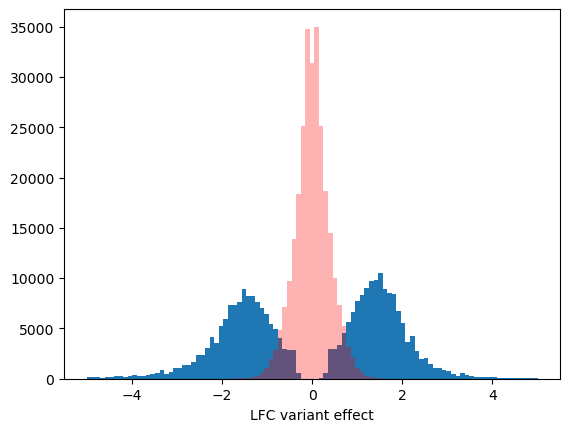

In [18]:
import matplotlib.pyplot as plt
bins = np.linspace(-5, 5, 100)
h = plt.hist(positives.logit_es, bins=bins)
h = plt.hist(negatives.logit_es, bins=bins, color="red", alpha=0.3)
plt.xlabel("LFC variant effect")

In [16]:
indiv_id_mapping = pd.read_table('/net/seq/data2/projects/sabramov/ENCODE4/dnase-cavs.v5/meta+sample_ids.tsv').set_index('sample_id')
indiv_id_mapping

,ln_number,ds_number,tc_number,core_annotation,extended_annotation,core_ontology_term,sample_type,system,subsystem,organ,...,total_cutcounts_file,cutcounts_tabix,SPOT1_score,SPOT3_score,total_fastq_reads,nuclear_reads,alignment_quality,nuclear_dup_rate,indiv_id,snps_file
sample_id,,,,,,,,,,,,,,,,,,,,,
AG10028,LN45952,DS58903,TC2653,Myeloid,CML,K562,Cell line,Hematopoietic,Myeloid,Blood,...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/p...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/p...,0.3182,0.074446,52520104,43150608,0.821602,0.090581,NaN,/net/seq/data2/projects/sabramov/ENCODE4/dnase...
AG10029,LN45951,DS58898,TC2652,Myeloid,CML,K562,Cell line,Hematopoietic,Myeloid,Blood,...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/p...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/p...,0.3060,0.057275,54654080,44625318,0.816505,0.097833,NaN,/net/seq/data2/projects/sabramov/ENCODE4/dnase...
AG10031,LN45947,DS58779,TC2652,Myeloid,CML,K562,Cell line,Hematopoietic,Myeloid,Blood,...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/p...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/p...,0.3236,0.084240,62032686,48761214,0.786057,0.121074,INDIV_0002,/net/seq/data2/projects/sabramov/ENCODE4/dnase...
AG10032,LN45945,DS58765,TC2650,Myeloid,CML,K562,Cell line,Hematopoietic,Myeloid,Blood,...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/p...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/p...,0.3407,0.092941,65021458,51644128,0.794263,0.117462,INDIV_0002,/net/seq/data2/projects/sabramov/ENCODE4/dnase...
AG10033,LN45944,DS58761,TC2649,Myeloid,CML,K562,Cell line,Hematopoietic,Myeloid,Blood,...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/p...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/p...,0.3458,0.099725,62713902,50214894,0.800698,0.109526,INDIV_0002,/net/seq/data2/projects/sabramov/ENCODE4/dnase...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AG70923,LN26979,DS28156,TC4770,Myeloid,Monocyte,CD14+ monocyte,Primary cells/tissues,Hematopoietic,Myeloid,Blood,...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/p...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/p...,0.2507,0.088885,21458764,14001510,0.652484,0.322671,NaN,/net/seq/data2/projects/sabramov/ENCODE4/dnase...
AG72731,LN54316,DS70424,TC8000,Fetal life support,Fetal life support,Placenta,Primary cells/tissues,Reproductive,NaN,Placenta,...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/p...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/p...,0.5123,0.316107,205268193,168995390,0.823291,0.329474,INDIV_0433,/net/seq/data2/projects/sabramov/ENCODE4/dnase...
AG4026,LN33516,DS40210,TC5870,Colon,Colon,Transverse colon,Primary cells/tissues,Digestive,NaN,Colon,...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/p...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/p...,0.2153,0.123919,217560462,110999900,0.510203,0.332484,INDIV_0015,/net/seq/data2/projects/sabramov/ENCODE4/dnase...


In [17]:
variants["indiv_id"] = (
    variants["sample_id"].map(indiv_id_mapping["indiv_id"]).fillna("").astype(str)
)

/tmp/slurm.8451417/ipykernel_79416/4127241232.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  variants["indiv_id"] = (


In [19]:
variants

,#chr,start,end,ID,ref,alt,ref_counts,alt_counts,sample_id,AAF,...,min_pval,FDR_sample,hotspots,footprints,peaks,inverse_mse,group_id,variant_id,total_counts,indiv_id
23,chr1,804903,804904,rs61770167,C,T,20,15,AG72381,0.004093,...,0.499560,0.937686,0,-,0,14.564382,all,chr1:804904:C:T,35,INDIV_0120
65,chr1,817185,817186,rs3094315,G,A,23,13,AG80733,0.706382,...,0.754975,1.000000,0,-,0,9.451293,all,chr1:817186:G:A,36,INDIV_0287
66,chr1,817185,817186,rs3094315,G,A,26,29,AG80823,0.706382,...,0.706269,0.971396,0,-,0,9.795636,all,chr1:817186:G:A,55,INDIV_0314
69,chr1,817185,817186,rs3094315,G,A,33,24,AG70842,0.706382,...,0.872472,0.891271,0,-,0,9.818754,all,chr1:817186:G:A,57,INDIV_0010
71,chr1,817185,817186,rs3094315,G,A,43,36,AG80260,0.706382,...,0.459450,0.937870,0,-,0,9.996950,all,chr1:817186:G:A,79,INDIV_0051
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48190720,chr9,138217445,138217446,rs11562371,C,T,19,21,AG80066,0.370349,...,0.874629,1.000000,0,-,0,15.569979,all,chr9:138217446:C:T,40,INDIV_0032
48190724,chr9,138217445,138217446,rs11562371,C,T,21,24,AG96533,0.370349,...,0.788662,1.000000,0,-,0,9.649918,all,chr9:138217446:C:T,45,INDIV_0138
48190725,chr9,138217445,138217446,rs11562371,C,T,22,29,AG80065,0.370349,...,0.401062,1.000000,0,-,0,17.580981,all,chr9:138217446:C:T,51,INDIV_0032
48190727,chr9,138217445,138217446,rs11562371,C,T,26,13,AG80357,0.370349,...,0.494174,1.000000,0,-,0,9.527468,all,chr9:138217446:C:T,39,INDIV_0070


In [20]:
import pandas as pd

# Assuming your DataFrame is called `variants`
# Define the columns to consider for uniqueness
key_cols = ["#chr", "start", "end", "indiv_id"]

# Keep only the first occurrence of each unique combination
variants_filtered = variants.drop_duplicates(subset=key_cols, keep=False)

# Check result
print(f"Original variants: {len(variants)}")
print(f"Filtered variants: {len(variants_filtered)}")


Original variants: 8076766
Filtered variants: 2344035


In [38]:
cols_to_show = ["#chr", "start", "end", "ID", "ref", "alt", "indiv_id","sample_id","FDR_sample","ref_counts","alt_counts"]

filtered_out = (
    variants.merge(
        variants_filtered[key_cols],
        on=key_cols,
        how="left",
        indicator=True
    )
    .query('_merge == "left_only"')
    [cols_to_show]
    .sort_values(by=["#chr", "start", "indiv_id"])
)

filtered_out.head(10)


,#chr,start,end,ID,ref,alt,indiv_id,sample_id,FDR_sample,ref_counts,alt_counts
5,chr1,817185,817186,rs3094315,G,A,INDIV_0094,AG80304,0.534222,8,36
6,chr1,817185,817186,rs3094315,G,A,INDIV_0094,AG80238,0.742493,9,36
7,chr1,817236,817237,rs149886465,C,A,INDIV_0094,AG80304,0.930318,28,8
8,chr1,817236,817237,rs149886465,C,A,INDIV_0094,AG80238,0.729882,31,7
15,chr1,817340,817341,rs3131972,A,G,INDIV_0009,AG70822,0.925758,15,22
16,chr1,817340,817341,rs3131972,A,G,INDIV_0009,AG70827,1.000000,15,24
19,chr1,817340,817341,rs3131972,A,G,INDIV_0009,AG70916,0.861856,17,39
27,chr1,817340,817341,rs3131972,A,G,INDIV_0009,AG70770,0.994219,20,32
38,chr1,817340,817341,rs3131972,A,G,INDIV_0009,AG70910,0.978671,24,46
43,chr1,817340,817341,rs3131972,A,G,INDIV_0009,AG70890,0.991685,26,27


In [63]:
filtered_out

,#chr,start,end,ID,ref,alt,indiv_id,sample_id,FDR_sample,ref_counts,alt_counts
5,chr1,817185,817186,rs3094315,G,A,INDIV_0094,AG80304,0.534222,8,36
6,chr1,817185,817186,rs3094315,G,A,INDIV_0094,AG80238,0.742493,9,36
7,chr1,817236,817237,rs149886465,C,A,INDIV_0094,AG80304,0.930318,28,8
8,chr1,817236,817237,rs149886465,C,A,INDIV_0094,AG80238,0.729882,31,7
15,chr1,817340,817341,rs3131972,A,G,INDIV_0009,AG70822,0.925758,15,22
...,...,...,...,...,...,...,...,...,...,...,...
8076743,chr9,138150219,138150220,rs11137386,G,A,INDIV_0073,AG72392,0.020171,46,17
8076722,chr9,138150219,138150220,rs11137386,G,A,INDIV_0119,AG92950,0.993270,23,19
8076746,chr9,138150219,138150220,rs11137386,G,A,INDIV_0119,AG92938,0.260302,52,26
8076761,chr9,138217445,138217446,rs11562371,C,T,INDIV_0032,AG80066,1.000000,19,21


In [57]:
# Count how many unique samples per allele/locus
replicate_counts = (
    filtered_out.groupby(["#chr", "start", "ref", "alt", "indiv_id"])
    ["sample_id"]
    .nunique()
    .reset_index(name="n_samples")
)

# Keep only loci that occur in more than one sample
replicate_only = replicate_counts[replicate_counts["n_samples"] > 1]

# Merge back to include sample_id rows
replicate_only_rows = filtered_out.merge(
    replicate_only[["#chr", "start", "ref", "alt", "indiv_id"]],
    on=["#chr", "start", "ref", "alt", "indiv_id"],
    how="inner"
).sort_values(by=["#chr", "start", "indiv_id", "sample_id"])


In [58]:

replicate_only_rows.head(10)


,#chr,start,end,ID,ref,alt,indiv_id,sample_id,FDR_sample,ref_counts,alt_counts
1,chr1,817185,817186,rs3094315,G,A,INDIV_0094,AG80238,0.742493,9,36
0,chr1,817185,817186,rs3094315,G,A,INDIV_0094,AG80304,0.534222,8,36
3,chr1,817236,817237,rs149886465,C,A,INDIV_0094,AG80238,0.729882,31,7
2,chr1,817236,817237,rs149886465,C,A,INDIV_0094,AG80304,0.930318,28,8
7,chr1,817340,817341,rs3131972,A,G,INDIV_0009,AG70770,0.994219,20,32
16,chr1,817340,817341,rs3131972,A,G,INDIV_0009,AG70813,0.977810,35,46
4,chr1,817340,817341,rs3131972,A,G,INDIV_0009,AG70822,0.925758,15,22
5,chr1,817340,817341,rs3131972,A,G,INDIV_0009,AG70827,1.000000,15,24
13,chr1,817340,817341,rs3131972,A,G,INDIV_0009,AG70847,0.934112,32,39
18,chr1,817340,817341,rs3131972,A,G,INDIV_0009,AG70850,0.934683,38,35


In [45]:
# Get only rows corresponding to multiallelic loci
true_multiallelic_rows = filtered_out.merge(
    true_multiallelic[key_cols],
    on=key_cols,
    how="inner"
).sort_values(by=key_cols + ["ref", "alt"])

In [46]:
true_multiallelic_rows.head(20)

,#chr,start,end,ID,ref,alt,indiv_id,sample_id,FDR_sample,ref_counts,alt_counts
0,chr1,16727286,16727287,.,C,A,INDIV_0463,AG81594,9.727688e-01,12,23
1,chr1,16727286,16727287,rs2419168,C,G,INDIV_0463,AG81594,9.727688e-01,12,35
16,chr1,21345691,21345692,rs7540855,A,C,INDIV_0003,AG72571,7.403199e-08,0,48
8,chr1,21345691,21345692,.,A,T,INDIV_0003,AG72571,1.837127e-10,0,61
11,chr1,21345691,21345692,rs7540855,A,C,INDIV_0003,AG72573,1.290757e-23,0,122
2,chr1,21345691,21345692,.,A,T,INDIV_0003,AG72573,1.475489e-22,0,117
19,chr1,21345691,21345692,rs7540855,A,C,INDIV_0003,AG72574,9.937176e-13,1,79
10,chr1,21345691,21345692,.,A,T,INDIV_0003,AG72574,4.466882e-15,1,91
18,chr1,21345691,21345692,rs7540855,A,C,INDIV_0003,AG72577,6.647841e-15,0,83
9,chr1,21345691,21345692,.,A,T,INDIV_0003,AG72577,2.532408e-17,0,95


In [64]:
true_multiallelic_rows.shape

(198, 11)

In [66]:
replicate_only_rows.shape

(5732707, 11)

In [67]:
filtered_out.shape

(5732731, 11)

In [68]:
5732731-5732707

24

In [ ]:
#WIP removing ambiguous

In [69]:
total_removed = len(filtered_out)
# replicate_only already has one row per locus (unique #chr, start, ref, alt, indiv_id)
frac_replicates = len(replicate_only_rows) / total_removed
print(f"Fraction due to replicates: {frac_replicates:.2%}")
frac_multiallelic = true_multiallelic_rows[key_cols].drop_duplicates().shape[0] / total_removed
print(f"Fraction due to true multiallelic: {frac_multiallelic:.2%}")


Fraction due to replicates: 100.00%
Fraction due to true multiallelic: 0.00%


In [48]:
summary = pd.DataFrame({
    "category": ["replicate", "true_multiallelic"],
    "count": [len(replicate_only), true_multiallelic_rows[key_cols].drop_duplicates().shape[0]],
    "fraction": [
        len(replicate_only)/total_removed,
        true_multiallelic_rows[key_cols].drop_duplicates().shape[0]/total_removed
    ]
})

summary


,category,count,fraction
0,replicate,1197491,0.208887
1,true_multiallelic,99,0.000017


In [61]:
key_cols = ["#chr", "start", "indiv_id", "sample_id", "ref", "alt"]
# Create boolean mask for rows NOT in replicate or multiallelic
mask = ~filtered_out.set_index(key_cols).index.isin(
    replicate_only_rows.set_index(key_cols).index
) & ~filtered_out.set_index(key_cols).index.isin(
    true_multiallelic_rows.set_index(key_cols).index
)

# Remaining rows
other_rows = filtered_out[mask].sort_values(by=["#chr", "start", "indiv_id", "sample_id"])


In [62]:
other_rows.head()

,#chr,start,end,ID,ref,alt,indiv_id,sample_id,FDR_sample,ref_counts,alt_counts


In [35]:
# Columns that define a duplicate at the sample level
key_cols = ["sample_id", "indiv_id", "#chr", "start"]

# Keep rows where this combination occurs more than once
mask = filtered_out.duplicated(subset=key_cols, keep=False)

dups_from_filtered = filtered_out[mask].sort_values(by=key_cols)


,#chr,start,end,ID,ref,alt,indiv_id,sample_id,FDR_sample,ref_counts,alt_counts
1028518,chr10,94363068,94363069,.,C,A,INDIV_0015,AG6232,6.551488e-10,0,46
1028564,chr10,94363068,94363069,rs7100870,C,T,INDIV_0015,AG6232,2.236241e-07,0,37
1028520,chr10,94363068,94363069,.,C,A,INDIV_0015,AG6242,5.916263e-11,0,48
1028575,chr10,94363068,94363069,rs7100870,C,T,INDIV_0015,AG6242,2.888800e-13,0,58
1028522,chr10,94363068,94363069,.,C,A,INDIV_0015,AG6260,2.320459e-13,0,56
1028579,chr10,94363068,94363069,rs7100870,C,T,INDIV_0015,AG6260,5.311108e-18,0,73
1028521,chr10,94363068,94363069,.,C,A,INDIV_0015,AG6436,8.519671e-13,0,54
1028577,chr10,94363068,94363069,rs7100870,C,T,INDIV_0015,AG6436,1.039999e-16,0,68
1028515,chr10,94363068,94363069,.,C,A,INDIV_0015,AG6942,2.149591e-09,0,43
1028563,chr10,94363068,94363069,rs7100870,C,T,INDIV_0015,AG6942,1.375738e-07,0,36


In [36]:
dups_from_filtered

,#chr,start,end,ID,ref,alt,indiv_id,sample_id,FDR_sample,ref_counts,alt_counts
1028518,chr10,94363068,94363069,.,C,A,INDIV_0015,AG6232,6.551488e-10,0,46
1028564,chr10,94363068,94363069,rs7100870,C,T,INDIV_0015,AG6232,2.236241e-07,0,37
1028520,chr10,94363068,94363069,.,C,A,INDIV_0015,AG6242,5.916263e-11,0,48
1028575,chr10,94363068,94363069,rs7100870,C,T,INDIV_0015,AG6242,2.888800e-13,0,58
1028522,chr10,94363068,94363069,.,C,A,INDIV_0015,AG6260,2.320459e-13,0,56
...,...,...,...,...,...,...,...,...,...,...,...
3267134,chr17,50346056,50346057,rs9912067,G,C,INDIV_0003,AG93413,6.789848e-10,0,41
309732,chr1,53889880,53889881,.,A,C,INDIV_0022,AG93485,3.121111e-08,0,48
310002,chr1,53889880,53889881,rs2272929,A,T,INDIV_0022,AG93485,1.194848e-05,0,35
309737,chr1,53889880,53889881,.,A,C,INDIV_0022,AG93488,2.971117e-08,1,54


In [28]:
filtered_out.groupby("indiv_id")["sample_id"].nunique() \
    .sort_values(ascending=False) 


indiv_id
INDIV_0001    290
INDIV_0002    251
INDIV_0003    223
INDIV_0004    111
INDIV_0005     85
             ... 
INDIV_0407      2
INDIV_0463      1
INDIV_0505      1
INDIV_0517      1
INDIV_0587      1
Name: sample_id, Length: 403, dtype: int64

In [29]:
filtered_out.groupby("sample_id") \
    .size() \
    .sort_values(ascending=False) 

sample_id
AG72573    21867
AG72597    19590
AG72577    18610
AG72574    18030
AG92866    17300
           ...  
AG80457        1
AG80634        1
AG80632        1
AG82581        1
AG80322        1
Length: 2957, dtype: int64

In [25]:
var_df = variants_filtered.drop_duplicates('variant_id').set_index('variant_id')[['#chr', 'start', 'end', 'ID', 'ref', 'alt', 'AAF', 'RAF']]

In [26]:
var_df

,#chr,start,end,ID,ref,alt,AAF,RAF
variant_id,,,,,,,,
chr1:804904:C:T,chr1,804903,804904,rs61770167,C,T,0.004093,0.995907
chr1:817186:G:A,chr1,817185,817186,rs3094315,G,A,0.706382,0.293323
chr1:817341:A:G,chr1,817340,817341,rs3131972,A,G,0.665607,0.334393
chr1:818094:C:G,chr1,818093,818094,rs2073814,C,G,0.631809,0.368191
chr1:818161:G:A,chr1,818160,818161,rs2073813,G,A,0.273334,0.726666
...,...,...,...,...,...,...,...,...
chr9:138155803:G:A,chr9,138155802,138155803,rs147604762,G,A,0.207585,0.792391
chr9:138155904:T:G,chr9,138155903,138155904,rs9410084,T,G,0.713892,0.286020
chr9:138155977:G:T,chr9,138155976,138155977,rs12683077,G,T,0.136850,0.863150


In [27]:
train_var_adata = ad.AnnData(X=None, var=var_df, obs=adata.obs)
train_var_adata

AnnData object with n_obs × n_vars = 4159 × 657558
    obs: 'ln_number', 'ds_number', 'tc_number', 'core_annotation', 'extended_annotation', 'core_ontology_term', 'sample_type', 'system', 'subsystem', 'organ', 'organ_region', 'side_position', 'pathological_state', 'germ_layer', 'read_type', 'donor_age', 'donor_age_units', 'donor_ethnicity', 'donor_health_condition', 'donor_id', 'donor_sex', 'growth_stage', 'indiv_id', 'sample_source', 'dnasei_units', 'harvest_time', 'harvest_time_units', 'library_date', 'library_method', 'sample_extra', 'tc_extra', 'tissue_preparation', 'tissue_purification', 'core_treatment_name', 'treatment1_conc_units', 'treatment1_concentration', 'treatment1_duration', 'treatment1_duration_units', 'treatment1_name', 'treatment1_type', 'treatment2_conc_units', 'treatment2_concentration', 'treatment2_duration', 'treatment2_duration_units', 'treatment2_name', 'treatment2_type', 'treatment3_concentration', 'treatment3_duration', 'treatment3_name', 'treatment3_type', 't

In [45]:
row_idx = train_var_adata.obs_names.get_indexer(variants["sample_id"])

# Map variant_id -> col index
col_idx = train_var_adata.var_names.get_indexer(variants["variant_id"])

for column in tqdm(['ref_counts', 'total_counts', 'BAD', 'logit_es', 'FDR_sample']):
    data = sp.coo_matrix(
        (variants[column], (row_idx, col_idx)),
        shape=train_var_adata.shape
    ).tocsr()
    train_var_adata.layers[column] = data


100%|██████████| 5/5 [00:00<00:00,  6.56it/s]


In [46]:
indiv_id_mapping['indiv_id']

sample_id
AG10028           NaN
AG10029           NaN
AG10031    INDIV_0002
AG10032    INDIV_0002
AG10033    INDIV_0002
              ...    
AG70923           NaN
AG72731    INDIV_0433
AG4026     INDIV_0015
AG4009     INDIV_0018
AG80141    INDIV_0363
Name: indiv_id, Length: 3480, dtype: object

In [47]:
train_var_adata.obsm['indiv_id'] = train_var_adata.obs_names.map(indiv_id_mapping['indiv_id']).fillna('').to_numpy().astype(str)

In [48]:
sampled_val = pd.Series(train_var_adata.obs_names).sample(50).values
validation_chroms = ['chr9', 'chr22']

In [49]:
train_var_adata.uns['epoch_names'] = ['epoch_1']
train_var_adata.uns['n_epochs'] = 1
train_var_adata.obsm['motif_embeddings'] = adata.obsm['motif_embeddings'].loc[train_var_adata.obs_names]
train_var_adata.obsm['split_data'] = np.where(train_var_adata.obs_names.isin(sampled_val), 'val', 'train')
train_var_adata.varm['split_data'] = np.where(train_var_adata.var['#chr'].isin(validation_chroms), 'val', 'train')
train_var_adata

AnnData object with n_obs × n_vars = 4159 × 757925
    obs: 'ln_number', 'ds_number', 'tc_number', 'core_annotation', 'extended_annotation', 'core_ontology_term', 'sample_type', 'system', 'subsystem', 'organ', 'organ_region', 'side_position', 'pathological_state', 'germ_layer', 'read_type', 'donor_age', 'donor_age_units', 'donor_ethnicity', 'donor_health_condition', 'donor_id', 'donor_sex', 'growth_stage', 'indiv_id', 'sample_source', 'dnasei_units', 'harvest_time', 'harvest_time_units', 'library_date', 'library_method', 'sample_extra', 'tc_extra', 'tissue_preparation', 'tissue_purification', 'core_treatment_name', 'treatment1_conc_units', 'treatment1_concentration', 'treatment1_duration', 'treatment1_duration_units', 'treatment1_name', 'treatment1_type', 'treatment2_conc_units', 'treatment2_concentration', 'treatment2_duration', 'treatment2_duration_units', 'treatment2_name', 'treatment2_type', 'treatment3_concentration', 'treatment3_duration', 'treatment3_name', 'treatment3_type', 't

In [50]:
for layer in list(train_var_adata.layers):
    train_var_adata.layers[f"{layer}.epoch_1"] = train_var_adata.layers[layer]
    del train_var_adata.layers[layer]

In [51]:
train_var_adata

AnnData object with n_obs × n_vars = 4159 × 757925
    obs: 'ln_number', 'ds_number', 'tc_number', 'core_annotation', 'extended_annotation', 'core_ontology_term', 'sample_type', 'system', 'subsystem', 'organ', 'organ_region', 'side_position', 'pathological_state', 'germ_layer', 'read_type', 'donor_age', 'donor_age_units', 'donor_ethnicity', 'donor_health_condition', 'donor_id', 'donor_sex', 'growth_stage', 'indiv_id', 'sample_source', 'dnasei_units', 'harvest_time', 'harvest_time_units', 'library_date', 'library_method', 'sample_extra', 'tc_extra', 'tissue_preparation', 'tissue_purification', 'core_treatment_name', 'treatment1_conc_units', 'treatment1_concentration', 'treatment1_duration', 'treatment1_duration_units', 'treatment1_name', 'treatment1_type', 'treatment2_conc_units', 'treatment2_concentration', 'treatment2_duration', 'treatment2_duration_units', 'treatment2_name', 'treatment2_type', 'treatment3_concentration', 'treatment3_duration', 'treatment3_name', 'treatment3_type', 't

In [52]:
train_var_adata.write_h5ad('/net/seq/data2/projects/mbrannon/variant_train_adata_wfdr.h5ad')

In [58]:
#take that anndata and split into 3 epochs
variant_file = '/net/seq/data2/projects/mbrannon/variant_train_adata_wfdr.h5ad'

In [59]:
import numpy as np
import scipy.sparse as sp
import anndata as ad
import gc
import matplotlib.pyplot as plt
from tqdm import tqdm


adata = ad.read_h5ad(variant_file)
n_rows, n_cols = adata.shape
print("Loaded AnnData:", adata.shape)


Loaded AnnData: (4159, 757925)


In [60]:
# ==================================================
# Build epoch indices (memory-efficient, real variants only)
# ==================================================
def build_epoch_indices_filtered(adata, epoch, seed=42):
    rng = np.random.default_rng(seed)

    # Source layers (all from epoch_1)
    layer_logit = adata.layers["logit_es.epoch_1"].tocoo()
    layer_ref   = adata.layers["ref_counts.epoch_1"].tocoo()
    layer_total = adata.layers["total_counts.epoch_1"].tocoo()
    layer_fdr = adata.layers["FDR_sample.epoch_1"].tocoo()

    # Compute alt and passed filter
    alt_data = layer_total.data - layer_ref.data
    passed_read_count = (layer_total.data > 20) & (layer_ref.data > 0) & (alt_data > 0)
    sig_if = (layer_fdr.data < 0.1) & (np.abs(layer_logit.data) < 6)
    neg_fdr = layer_fdr.data > 0.5
    # --------------------
    # Positives: |logit| < 6
    # --------------------
    pos_mask = passed_read_count & sig_if
    pos_rows = layer_logit.row[pos_mask]
    pos_cols = layer_logit.col[pos_mask]

    # --------------------
    # Negatives: |logit| < 0.1 (or whatever you want)
    # --------------------
    neg_mask = passed_read_count & neg_fdr
    neg_rows = layer_logit.row[neg_mask]
    neg_cols = layer_logit.col[neg_mask]

    # --------------------
    # Balance positives/negatives
    # --------------------
    n_pos = len(pos_rows)
    n_neg = len(neg_rows)
    print(f'n_pos {n_pos}')
    print(f'n_neg {n_neg}')
    if n_neg < n_pos:
        # downsample positives, no
        print('downsampling')
        keep_pos_idx = rng.choice(n_pos, size=n_neg, replace=False)
        pos_rows = pos_rows[keep_pos_idx]
        pos_cols = pos_cols[keep_pos_idx]
        n_pos = n_neg
    else:
        # downsample negatives
        keep_neg_idx = rng.choice(n_neg, size=n_pos, replace=False)
        neg_rows = neg_rows[keep_neg_idx]
        neg_cols = neg_cols[keep_neg_idx]
        n_neg = n_pos

    # --------------------
    # Combine indices to keep
    # --------------------
    keep_rows = np.concatenate([pos_rows, neg_rows])
    keep_cols = np.concatenate([pos_cols, neg_cols])

    print(f"{epoch}: {n_pos} positives, {n_neg} negatives, total {len(keep_rows)}")
    return pos_rows, pos_cols, neg_rows, neg_cols, keep_rows, keep_cols

# ==================================================
# Build new sparse AnnData with multiple epochs
# ==================================================
def build_epoch_anndata_sparse_filtered(adata, epochs=("epoch_1", "epoch_2", "epoch_3")):
    new = ad.AnnData(
        X=None,
        obs=adata.obs.copy(),
        var=adata.var.copy(),
        obsm=adata.obsm,
        varm=adata.varm,
        uns={"epoch_names": list(epochs)},
    )

    epoch_indices = {}

    for i, epoch in enumerate(tqdm(epochs, desc="Epochs")):
        pos_r, pos_c, neg_r, neg_c, keep_r, keep_c = build_epoch_indices_filtered(
            adata, epoch, seed=100 + i
        )
        epoch_indices[epoch] = {
            "pos": (pos_r, pos_c),
            "neg": (neg_r, neg_c),
            "keep": (keep_r, keep_c)
        }

        # Build layers
        for key in tqdm(["ref_counts", "total_counts", "BAD", "logit_es", "FDR_sample"],
                        desc=f"Building layers for {epoch}", leave=False):
            src_layer = adata.layers[f"{key}.epoch_1"].tocoo()
            # Build a dict mapping nonzero positions
            data_dict = {(r, c): v for r, c, v in zip(src_layer.row, src_layer.col, src_layer.data)}

            # Fill values for kept indices, zero if absent
            layer_data = np.array([data_dict.get((r, c), 0) for r, c in zip(keep_r, keep_c)],
                                  dtype=src_layer.data.dtype)
            new.layers[f"{key}.{epoch}"] = sp.csr_matrix((layer_data, (keep_r, keep_c)), shape=adata.shape)
        gc.collect()

    return new, epoch_indices

# ==================================================
# Build epochs
# ==================================================
epochs = ["epoch_1", "epoch_2", "epoch_3"]
epoch_adata, epoch_indices = build_epoch_anndata_sparse_filtered(adata, epochs=epochs)

Epochs:   0%|          | 0/3 [00:00<?, ?it/s]

n_pos 275909
n_neg 7297744
epoch_1: 275909 positives, 275909 negatives, total 551818



Epochs:  33%|███▎      | 1/3 [01:10<02:21, 70.75s/it]                     

n_pos 275909
n_neg 7297744
epoch_2: 275909 positives, 275909 negatives, total 551818



Epochs:  67%|██████▋   | 2/3 [02:18<01:08, 68.73s/it]                     

n_pos 275909
n_neg 7297744
epoch_3: 275909 positives, 275909 negatives, total 551818



Epochs: 100%|██████████| 3/3 [03:24<00:00, 68.30s/it]                     


In [61]:
#check spread

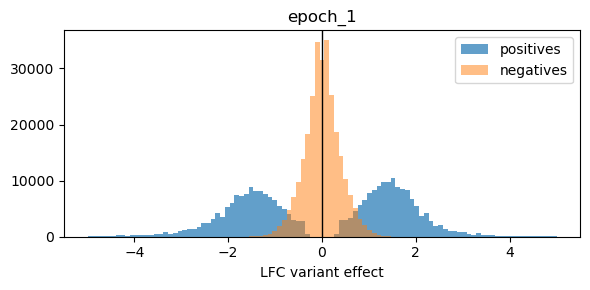

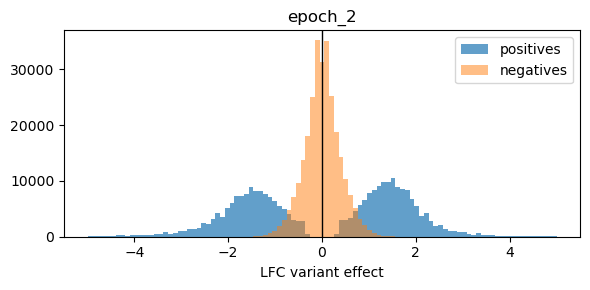

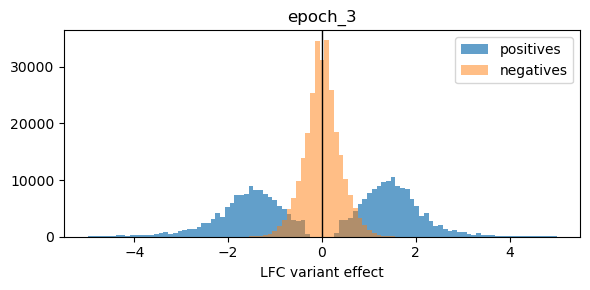

In [62]:
# ==================================================
# Sanity check histograms (match pandas)
# ==================================================
bins = np.linspace(-5, 5, 100)
for epoch, idx_dict in epoch_indices.items():
    logit = epoch_adata.layers[f"logit_es.{epoch}"]

    pos_rows, pos_cols = idx_dict["pos"]
    neg_rows, neg_cols = idx_dict["neg"]

    pos_vals = logit[pos_rows, pos_cols].A1
    neg_vals = logit[neg_rows, neg_cols].A1

    plt.figure(figsize=(6, 3))
    plt.hist(pos_vals, bins=bins, alpha=0.7, label="positives")
    plt.hist(neg_vals, bins=bins, alpha=0.5, label="negatives")
    plt.axvline(0, color="black", lw=1)
    plt.title(epoch)
    plt.xlabel("LFC variant effect")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [63]:
#bounds check
# ==================================================
print("\nRunning sanity checks...")
assert "epoch_names" in epoch_adata.uns
for epoch in epoch_adata.uns["epoch_names"]:
    for base in ["ref_counts", "total_counts", "BAD", "logit_es", "FDR_sample"]:
        layer = f"{base}.{epoch}"
        assert layer in epoch_adata.layers, f"Missing {layer}"
        assert epoch_adata.layers[layer].shape == epoch_adata.shape
print("✔ All epoch layers present")
print("✔ Shapes consistent")
print("✔ Ready for training")


Running sanity checks...
✔ All epoch layers present
✔ Shapes consistent
✔ Ready for training


In [64]:
# ==================================================
# Save
# ==================================================
out_file = "/net/seq/data2/projects/mbrannon/vinson/variant_train_adata_balanced_epochs3.h5ad"
epoch_adata.write_h5ad(out_file, compression="gzip")
print("Saved:", out_file)

Saved: /net/seq/data2/projects/mbrannon/vinson/variant_train_adata_balanced_epochs3.h5ad


In [ ]:
#then run in scripts elim ambig

srun --mem=200G python scripts/elim_ambig.py \
    --input_h5 /net/seq/data2/projects/mbrannon/vinson/variant_train_adata_balanced_epochs3.h5ad \
    --output_h5 /net/seq/data2/projects/mbrannon/vinson/variant_train_adata_epochs_balanced_noambig_epoch3_jitter40.h5ad \
    --fasta /net/seq/data/genomes/human/GRCh38/noalts/GRCh38_no_alts.fa \
    --genotype /net/seq/data2/projects/sabramov/ENCODE4/dnase-wasp.v5/phasing/output/all_phased.bed.gz
    --jitter 40


In [ ]:
#then train 

In [ ]:
python submit_to_sbatch.py /net/seq/data2/projects/mbrannon/vinson/variant_train_adata_epochs_balanced_noambig_epoch3_jitter40.h5ad \
/net/seq/data/genomes/human/GRCh38/noalts/GRCh38_no_alts.fa \
/net/seq/data2/projects/sabramov/ENCODE4/dnase-wasp.v5/phasing/output/all_phased.bed.gz \
/net/seq/data2/projects/mbrannon/variant_model_legnet \
--config /home/mbrannon/.local/src/vinson/train/jan21_legnet.yaml \
--model_type variant \
--env_path /home/mbrannon/.local/miniconda3/envs/pytorch_clone \
--mem 200G  \
--nodelist hpcg04-heavy --debug

In [35]:
!ls  /net/seq/data2/projects/ENCODE4Plus/REGULOME/sequence_to_accessibility_model/dnase_legnet/NOV03_rerun_DS_more_parameters/predictions

all_per_sample_predictions+annotations.val.pq
all_per_sample_predictions.finetuned.val.pq
all_per_sample_predictions.val.pq
chunk1082_3490_1.tsv
finetuning
output
per_sample_predictions_meta.base_model.human+mouse+cancer.tsv
plot_data.tsv
replicates
repurposing_dhs_meta.tsv
top_cell_selective_dhss_meta_JAN16.tsv
work


In [ ]:
/net/seq/data2/projects/mbrannon/vinson/variant_train_adata_epochs_balanced_noambig_epoch3_jitter40.h5ad